In [1]:
from datetime import datetime
import pickle
import os

import numpy as np
import pandas as pd
import lingam
from scipy.stats import kendalltau

import matplotlib.pyplot as plt

np.random.seed(0)

## 参考用テストデータ

(10000, 6)
[-0.01100208 -0.01525651 -0.00441799 -0.00616337 -0.0105817  -0.01169193]


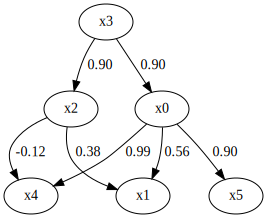

In [2]:
m = np.array([
    [ 0.000,  0.000,  0.000,  0.895,  0.000,  0.000],
    [ 0.565,  0.000,  0.377,  0.000,  0.000,  0.000],
    [ 0.000,  0.000,  0.000,  0.895,  0.000,  0.000],
    [ 0.000,  0.000,  0.000,  0.000,  0.000,  0.000],
    [ 0.991,  0.000, -0.124,  0.000,  0.000,  0.000],
    [ 0.895,  0.000,  0.000,  0.000,  0.000,  0.000]
])

sample_size = 10000

error_vars = [0.2, 0.2, 0.2, 1.0, 0.2, 0.2]
params = [0.5 * np.sqrt(12 * v) for v in error_vars]

generate_error = lambda p: np.random.uniform(-p, p, size=sample_size)
e = np.array([generate_error(p) for p in params])

X = np.linalg.pinv(np.eye(len(m)) - m) @ e
X = X.T

print(X.shape)

# 平均ゼロは前提
print(X.mean(axis=0))

lingam.utils.make_dot(m)

## Low dimensional consstency

In [3]:
def make_dag_and_errors(n_nodes, sample_size, J=3):
    dag = np.zeros((n_nodes, n_nodes))
    errors = None
    
    # For each node v
    for v in range(n_nodes):        
        #  select the number of parents
        num_pa = np.random.choice(np.arange(min(n_nodes, J)))

        if v - 1 >= 0:
            # We include edge (v − 1, v) to ensure that the ordering is unique
            dag[v, v - 1] = np.random.choice([-1, 1]) * np.random.uniform(0.5, 1)

        # The remaining parents are selected uniformly from [v − 2]
        candidates = np.arange(v - 1)
        if len(candidates) == 0:
            continue

        pa = np.random.choice(candidates, size=num_pa)

        # the corresponding edge weights are set to +-1/5
        dag[v, pa] = np.random.uniform(-1/5, 1/5, size=len(pa))

    # The n error terms for variable v are generated by selecting σv ∼ unif(.8, 1)
    # drawing εvi ∼ σvunif(−√3,√3).
    errors = np.random.uniform(-np.sqrt(3), np.sqrt(3), size=(sample_size, n_nodes))
    errors = errors * np.random.uniform(0.8, 1, size=n_nodes)

    return dag, errors

## テスト

対角の下に必ず値があるので順位は一意に定まる。

ループ5回で30秒。100倍ならば1時間弱かかるだろう。

In [4]:
def run_test(p_list=None, n_list_func=None, loop_num=500, make_func=None, disable_direct=False):

    test_start = datetime.now()

    results = {}
    
    if p_list is None:
        p_list = np.arange(5, 25, 5, dtype=int)
    
    if n_list_func is None:
        n_list_func = lambda p: [10 * p, 50 * p]
        
    if make_func is None:
        make_func = make_dag_and_errors

    for p in p_list:
        true_order = np.arange(p)

        for n in n_list_func(p):
            print(f"p={p:2d}, n={n:2d}")

            evals_high_d = []
            evals_normal = []

            start = datetime.now()

            for i in range(loop_num):
                print(f"\r{i:3d} / {loop_num}", end="")

                dag, errors = make_func(p, n)
                
                X = (np.linalg.pinv(np.eye(p) - dag) @ errors.T).T

                #high_d_model = lingam.DirectLiNGAM(enable_high_dim=True, disable_est_adj=True)
                high_d_model = lingam.HighDimDirectLiNGAM()
                high_d_model.fit(X)

                if not disable_direct:
                    #normal_model = lingam.DirectLiNGAM(enable_high_dim=False, disable_est_adj=True)
                    normal_model = lingam.DirectLiNGAM()
                    normal_model.fit(X)

                eval_high_d = kendalltau(high_d_model.causal_order_, true_order).statistic
                evals_high_d.append(eval_high_d)

                if disable_direct:
                    eval_normal = None
                else:
                    eval_normal = kendalltau(normal_model.causal_order_, true_order).statistic
                evals_normal.append(eval_normal)

            print("\rcomplete: {:10.2f}s".format((datetime.now() - start).total_seconds()))

            results[(n, p)] = {
                "high_d": evals_high_d,
                "normal": evals_normal,
            }
            
            # ここで保存してもいいかも。
            
    total_seconds = (datetime.now() - test_start).total_seconds()
    print("total time {}s".format(total_seconds))
    
    max_p = max(p_list)
    max_n = max(n_list_func(max_p))
    fname = datetime.now().strftime('%Y%m%d%H%M%S') + f"_{max_p}_{max_n}_{loop_num}.bin"
    
    with open(fname, "wb") as f:
        pickle.dump(results, f)
    
    print(f"\nThe result has been saved as {fname}.")
    
    return results

if True:
    results = run_test(loop_num=500)
else:
    # 3000sec
    with open("20240607111046_20_1000_500.bin", "rb") as f:
        results = pickle.load(f)

p= 5, n=50
complete:      15.84s
p= 5, n=250
complete:      15.97s
p=10, n=100
complete:     107.06s
p=10, n=500
complete:     120.50s
p=15, n=150
complete:     339.30s
p=15, n=750
complete:     504.18s
p=20, n=200
complete:     788.92s
p=20, n=1000
complete:    1137.09s
total time 3028.872668s

The result has been saved as 20240614184252_20_1000_500.bin.


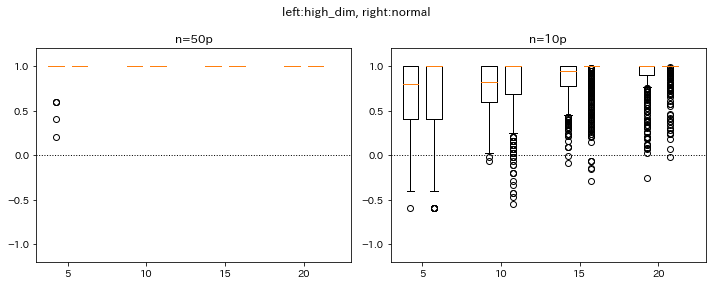

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for (n, p), evals in results.items():
    ax = axes[0] if n / p == 50.0 else axes[1]
    
    ax.boxplot(
        evals["high_d"],
        positions=[p - 0.75],
        widths=1,
    )

    ax.boxplot(
        evals["normal"],
        positions=[p + 0.75],
        widths=1,
    )
    
axes[0].set_title("n=50p")
axes[1].set_title("n=10p")
axes[0].set_ylim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)
axes[0].set_xlim(3, 23)
axes[1].set_xlim(3, 23)
axes[0].axhline(0, color="black", lw=1, ls="dotted")
axes[1].axhline(0, color="black", lw=1, ls="dotted")
axes[0].set_xticks([5, 10, 15, 20])
axes[1].set_xticks([5, 10, 15, 20])
axes[0].set_xticklabels([5, 10, 15, 20])
axes[1].set_xticklabels([5, 10, 15, 20])
plt.suptitle("left:high_dim, right:normal")
plt.tight_layout()

## High dimensional consistency

対角成分下の部分はエッジありで、その他はノード0,1,2をハブとするエッジだけになるみたい。

誤差がガンマ分布やガウシアンの時の実験も要るのだろうか？

In [6]:
def make_dag_and_errors2(n_nodes, sample_size, J=2):
    dag = np.zeros((n_nodes, n_nodes))
    errors = None
    
    # We first consider random DAGs and data generated as before, but with J = 2
    # 先ほどと同じ。Jの値と係数の値の範囲が違う。
    # For each node v
    for v in range(n_nodes):        
        #  select the number of parents
        num_pa = np.random.choice(np.arange(min(n_nodes, J)))

        if v - 1 >= 0:
            # We include edge (v − 1, v) to ensure that the ordering is unique
            dag[v, v - 1] = np.random.choice([-1, 1]) * np.random.uniform(0.65, 1)

        # The remaining parents are selected uniformly from [v − 2]
        candidates = np.arange(v - 1)
        if len(candidates) == 0:
            continue

        pa = np.random.choice(candidates, size=num_pa)

        # the corresponding edge weights are set to +-1/5
        dag[v, pa] = np.random.uniform(-1/5, 1/5, size=len(pa))
    #display(pd.DataFrame(dag))

    # add hubs
    # 非hubノードはいずれかのハブからのエッジを受けること。対角直下は決まっているので手をださないこと。
    for v in np.arange(3, n_nodes):
        # ハブの選択と係数の作成
        coefs = np.zeros(3)
        
        if v == 3:
            # 変数3のみ特別処理。変数2との接続は強制なのでそれ以外から選ぶ。
            index = np.random.choice([0, 1])
        else:
            index = np.random.choice([0, 1, 2])
            
        coefs[index] = np.random.uniform(-1/5, 1/5)

        # すでに係数が設定してあれば、そちらを優先する。coefはdag側が0である部分のみ非ゼロになる。
        filter_ = ~np.isclose(dag[v, :3], 0)
        coefs[filter_] = 0
        
        # フィルタしているので足して設定する
        dag[v, :3] += coefs

    # disturbances
    errors = np.random.uniform(-np.sqrt(3), np.sqrt(3), size=(sample_size, n_nodes))
    errors = errors * np.random.uniform(0.8, 1, size=n_nodes)

    return dag, errors

if True:
    dag, errors = make_dag_and_errors2(10, 100)
    display(pd.DataFrame(dag))
    
    # チェック
    for i in range(1000):
        dag, errors = make_dag_and_errors2(10, 10)
        # 対角から上は全部0
        assert (np.triu(dag) == 0).sum(axis=None) == 100
        # 1を超えるものは存在しない
        assert (np.abs(dag) > 1).sum() == 0
        # 非ハブは最低一つのハブを親に持つ。
        assert all((~np.isclose(dag[3:, :3], 0)).sum(axis=1) > 0)

,0,1,2,3,4,5,6,7,8,9
0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0
1,0.901576,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0
2,-0.054292,0.809123,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0
3,0.000000,-0.164948,-0.953258,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0
4,0.000000,0.035263,0.000000,0.850722,0.00000,0.000000,0.000000,0.000000,0.000000,0.0
5,0.000000,-0.018422,0.000000,0.000000,0.95108,0.000000,0.000000,0.000000,0.000000,0.0
6,0.000000,0.000000,-0.041477,0.000000,0.00000,0.852796,0.000000,0.000000,0.000000,0.0
7,0.000000,0.000000,0.186492,0.000000,0.00000,0.017108,0.702684,0.000000,0.000000,0.0
8,0.000000,0.000000,-0.127296,0.143922,0.00000,0.000000,0.000000,-0.977889,0.000000,0.0
9,-0.146576,-0.137035,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-0.675852,0.0


DirectLiNGAM抜きで、p=100だと100sec。p=200だと780秒。13分。
係数を求めるのをやめると？P=100で88秒。p=200だと746秒。

In [7]:
p_list = [100, 200, 500, 1000, 1500, 2000]
# ノード数よりもサンプル数が小さくなってしまってLassoLarsICが動かないみたい。
#n_list_func = lambda p: [int((3 / 4) * p)]
n_list_func = lambda p: [p + 1]

results = run_test(p_list=p_list, n_list_func=n_list_func, loop_num=1, make_func=make_dag_and_errors2, disable_direct=True)

p=100, n=101
complete:     100.32s
p=200, n=201
  0 / 1

KeyboardInterrupt: 